In [12]:
# ## Imports

import pickle
import numpy as np
import pandas as pd
import json
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from pathlib import Path

OUTPUT_DIR = Path("../../outputs/models")


## 1. Data Splitting

The cleaned dataset is split into training (70%), validation (15%), and test (15%) sets using `split_dataset`, stratified by both sex and CVD status. Split sizes are saved to config for validation across all downstream notebooks.

In [13]:
# ## 1 · Data Splitting

def split_dataset(csv_path, save_prefix=None, test_size=0.15, val_size=0.1765, random_state=42):
    """
    Loads a CSV, creates stratified train/val/test splits by cardio × gender.

    Args:
        csv_path     : path to CSV file
        save_prefix  : if provided, saves to ../data/test_train_val_sets/{prefix}_*.csv
        test_size    : proportion for test set (default 0.2)
        val_size     : proportion of train for val (default 0.2 → ~16% of total)
        random_state : random seed

    Returns:
        train_df, val_df, test_df
    """
    df = pd.read_csv(csv_path)
    df["stratify"] = df["cardio"].astype(str) + "_" + df["gender"].astype(str)

    train_df, test_df = train_test_split(
        df, test_size=test_size, stratify=df["stratify"], random_state=random_state,
    )
    train_df, val_df = train_test_split(
        train_df, test_size=val_size, stratify=train_df["stratify"], random_state=random_state,
    )

    print(f"Dataset    : {csv_path}")
    print(f"Train      : {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
    print(f"Val        : {len(val_df)}   ({len(val_df)/len(df)*100:.1f}%)")
    print(f"Test       : {len(test_df)}  ({len(test_df)/len(df)*100:.1f}%)")

    if save_prefix:
        base = "../../data/test_train_val_sets"
        train_df.to_csv(f"{base}/{save_prefix}_train.csv", index=False)
        val_df.to_csv(f"{base}/{save_prefix}_val.csv",     index=False)
        test_df.to_csv(f"{base}/{save_prefix}_test.csv",   index=False)
        print(f"Saved to {base}/{save_prefix}_*.csv")
    sizes = {
    "train": len(train_df),
    "val":   len(val_df),
    "test":  len(test_df)
    }
    with open("../../config/dataset_split_sizes.json", "w") as f:
        json.dump(sizes, f, indent=4)
    print("Saved dataset sizes:", sizes)

    return train_df, val_df, test_df



train_df, val_df, test_df = split_dataset(
    "../../data/processed/cardio_baseline_clean.csv",
    save_prefix="cardio_baseline",
)

Dataset    : ../../data/processed/cardio_baseline_clean.csv
Train      : 47721 (70.0%)
Val        : 10229   (15.0%)
Test       : 10227  (15.0%)
Saved to ../../data/test_train_val_sets/cardio_baseline_*.csv
Saved dataset sizes: {'train': 47721, 'val': 10229, 'test': 10227}


## 2. Split Validation Table

Confirms that the sex ratio and class balance are preserved across all three sets.

In [14]:
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

def get_rows(df, name):
    total = len(df)
    rows  = []
    for sex, label in [(0, "Female"), (1, "Male")]:
        sex_df = df[df["gender"] == sex]
        n      = len(sex_df)
        cvd    = (sex_df["cardio"] == 1).sum()
        no_cvd = (sex_df["cardio"] == 0).sum()
        rows.append([
            name, label, n,
            f"{n/total*100:.1f}%",
            cvd, f"{cvd/n*100:.1f}%",
            no_cvd, f"{no_cvd/n*100:.1f}%"
        ])
    return rows

table_rows = get_rows(train_df, "Train") + get_rows(val_df, "Val") + get_rows(test_df, "Test")

# ── Styles ────────────────────────────────────────────────
THIN        = Side(style="thin", color="AAAAAA")
BORDER      = Border(left=THIN, right=THIN, top=THIN, bottom=THIN)
CENTER      = Alignment(horizontal="center", vertical="center", wrap_text=True)
LEFT        = Alignment(horizontal="left",   vertical="center", wrap_text=True)
HEADER_FONT = Font(name="Arial", bold=True, size=10)
BODY_FONT   = Font(name="Arial", size=9)

def style(cell, font, fill_hex, alignment, border):
    cell.font      = font
    cell.fill      = PatternFill("solid", start_color=fill_hex)
    cell.alignment = alignment
    cell.border    = border

wb = Workbook()
ws = wb.active
ws.title = "Split Validation"

# ── Row 1: top-level headers ──────────────────────────────
for merge, label, fill_hex in [
    ("A1:A2", "Split",    "F0F0F0"),
    ("B1:B2", "Group",    "F0F0F0"),
    ("C1:C2", "N",        "F0F0F0"),
    ("D1:D2", "% of Set", "F0F0F0"),
    ("E1:F1", "CVD",      "DCE8F5"),
    ("G1:H1", "No CVD",   "D5EAD5"),
]:
    ws.merge_cells(merge)
    cell = ws[merge.split(":")[0]]
    cell.value = label
    style(cell, HEADER_FONT, fill_hex, CENTER, BORDER)

# ── Row 2: sub-headers ────────────────────────────────────
for col, label, fill_hex in [
    ("E", "N", "E8EEF5"), ("F", "%", "E8EEF5"),
    ("G", "N", "E2F0E2"), ("H", "%", "E2F0E2"),
]:
    cell = ws[f"{col}2"]
    cell.value = label
    style(cell, HEADER_FONT, fill_hex, CENTER, BORDER)

# ── Data rows ─────────────────────────────────────────────
prev_split = None
for r_idx, row in enumerate(table_rows, start=3):
    fill_hex   = "FFFFFF" if r_idx % 2 == 0 else "F9F9F9"
    split_label = row[0] if row[0] != prev_split else ""
    prev_split  = row[0]
    display_row = [split_label] + row[1:]
    for c_idx, val in enumerate(display_row, start=1):
        cell = ws.cell(row=r_idx, column=c_idx, value=val)
        style(cell, BODY_FONT, fill_hex, LEFT if c_idx <= 2 else CENTER, BORDER)

# ── Column widths ─────────────────────────────────────────
for col_idx, width in enumerate([10, 10, 8, 10, 8, 10, 8, 10], start=1):
    ws.column_dimensions[get_column_letter(col_idx)].width = width
ws.row_dimensions[1].height = 18
ws.row_dimensions[2].height = 18

wb.save(OUTPUT_DIR / "split_validation_table.xlsx")
print("Saved - split_validation_table.xlsx")

Saved - split_validation_table.xlsx


## 3. Prepare Features and Labels

Target and stratify columns are removed before training so neither can influence the model's predictions.

In [15]:
# ## 2 · Prepare X / y

X_train = train_df.drop(columns=["cardio", "stratify"])
y_train = train_df["cardio"]

X_val = val_df.drop(columns=["cardio", "stratify"])
y_val = val_df["cardio"]

X_test = test_df.drop(columns=["cardio", "stratify"])
y_test = test_df["cardio"]

female_mask_test = test_df["gender"].values == 0
male_mask_test   = test_df["gender"].values == 1


## 5. Training and Validation

Early stopping check confirms the model halted at the right point. Serialisation check confirms predictions are identical before and after saving.

In [16]:
# ## 3 · Train Baseline Model

model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    early_stopping_rounds=10,
)

model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=True)

with open("../baseline_models/cardio_xgb_baseline_model.pkl", "wb") as f:
    pickle.dump(model, f)

[0]	validation_0-logloss:0.68051
[1]	validation_0-logloss:0.66910
[2]	validation_0-logloss:0.65879
[3]	validation_0-logloss:0.64942
[4]	validation_0-logloss:0.64093
[5]	validation_0-logloss:0.63312
[6]	validation_0-logloss:0.62602
[7]	validation_0-logloss:0.61950
[8]	validation_0-logloss:0.61356
[9]	validation_0-logloss:0.60809
[10]	validation_0-logloss:0.60311
[11]	validation_0-logloss:0.59855
[12]	validation_0-logloss:0.59432
[13]	validation_0-logloss:0.59047
[14]	validation_0-logloss:0.58691
[15]	validation_0-logloss:0.58360
[16]	validation_0-logloss:0.58067
[17]	validation_0-logloss:0.57783
[18]	validation_0-logloss:0.57525
[19]	validation_0-logloss:0.57285
[20]	validation_0-logloss:0.57070
[21]	validation_0-logloss:0.56872
[22]	validation_0-logloss:0.56683
[23]	validation_0-logloss:0.56511
[24]	validation_0-logloss:0.56350
[25]	validation_0-logloss:0.56205
[26]	validation_0-logloss:0.56068
[27]	validation_0-logloss:0.55943
[28]	validation_0-logloss:0.55826
[29]	validation_0-loglos

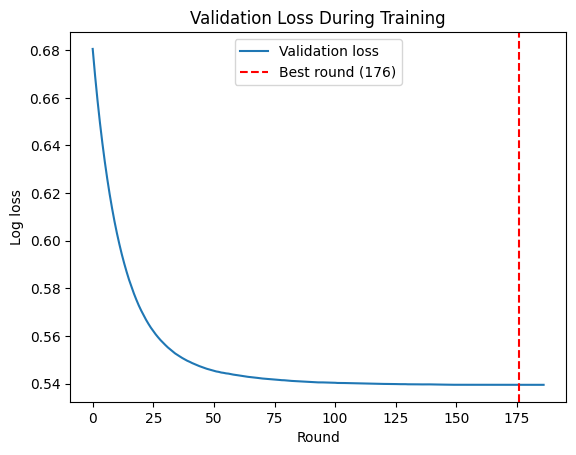

In [19]:
results = model.evals_result()
plt.plot(results["validation_0"]["logloss"], label="Validation loss")
plt.axvline(x=model.best_iteration, color="red", linestyle="--", label=f"Best round ({model.best_iteration})")
plt.xlabel("Round")
plt.ylabel("Log loss")
plt.title("Validation Loss During Training")
plt.legend()
plt.savefig("../../outputs/preprocessing/validation_loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
# Early stopping check
print(f"Best iteration: {model.best_iteration}")
print(f"Best validation loss: {model.best_score:.5f}")

# Serialisation check
with open("../baseline_models/cardio_xgb_baseline_model.pkl", "rb") as f:
    model_reloaded = pickle.load(f)

original_preds = model.predict_proba(X_test)[:, 1]
reloaded_preds = model_reloaded.predict_proba(X_test)[:, 1]

print(f"Predictions identical after reload: {np.allclose(original_preds, reloaded_preds)}")

Best iteration: 176
Best validation loss: 0.53947
Predictions identical after reload: True
